In [11]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

from src.models import SIRM, SIRT, SIRV
from helps import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
temp = read_json("./parameters.json")
mus, taus, xis, PARAMS = temp["mus"], temp["taus"], temp["xis"], temp["PARAMS"]
rect_coords_M = [mus["pol"][0], mus["h"][0], mus["pol"][2]-mus["pol"][0], mus["h"][2]-mus["h"][0]]
rect_coords_T = [taus["pol"][0], taus["h"][0], taus["pol"][2]-taus["pol"][0], taus["h"][2]-taus["h"][0]]
rect_coords_V = [xis["pol"][0], xis["h"][0], xis["pol"][2]-xis["pol"][0], xis["h"][2]-xis["h"][0]]

In [ ]:
NB = 100
NP = 100

homophilic_tendency = {"m": 0, "M": 6, "n": NB}
pol_range = {"m": 0, "M": 1, "n": NP}
PARAMS["beta_M"] = 0.2



PARAMS["fixed_mean"] = 0.5
RM_1_L = sweep_two_parameters(
    model_module=SIRM,
    param1_name="beta_params",           # parameter 1 name
    param1_range=pol_range,    # parameter 1 range
    param2_name="homophilic_tendency",      # parameter 2 name
    param2_range=homophilic_tendency,         # parameter 2 range
    custom_base_params=PARAMS,
    simulated_days=10000,
    population_size=20,
    batch_size=10000
)
PARAMS["beta_M"] = 0.4
RM_1_H = sweep_two_parameters(
    model_module=SIRM,
    param1_name="beta_params",           # parameter 1 name
    param1_range=pol_range,    # parameter 1 range
    param2_name="homophilic_tendency",      # parameter 2 name
    param2_range=homophilic_tendency,         # parameter 2 range
    custom_base_params=PARAMS,
    simulated_days=10000,
    population_size=20,
    batch_size=10000
)

PARAMS["fixed_mean"] = mus["mean"][1]
RM_2 = sweep_two_parameters(
    model_module=SIRM,
    param1_name="beta_params",           # parameter 1 name
    param1_range=pol_range,    # parameter 1 range
    param2_name="homophilic_tendency",      # parameter 2 name
    param2_range=homophilic_tendency,         # parameter 2 range
    custom_base_params=PARAMS,
    simulated_days=1000,
    population_size=20,
    batch_size=1000
)
PARAMS["beta_M"] = 0.2



In [19]:
NB = 100
NP = 100

homophilic_tendency = {"m": 0, "M": 6, "n": NB}
pol_range = {"m": 0, "M": 1, "n": NP}

PARAMS["fixed_mean"] = 0.5
RT_1_L = sweep_two_parameters(
    model_module=SIRT,
    param1_name="beta_params",           # parameter 1 name
    param1_range=pol_range,    # parameter 1 range
    param2_name="homophilic_tendency",      # parameter 2 name
    param2_range=homophilic_tendency,         # parameter 2 range
    custom_base_params=PARAMS,
    simulated_days=10000,
    population_size=20,
    batch_size=10000
)
PARAMS["beta_M"] = 0.4
RT_1_H = sweep_two_parameters(
    model_module=SIRT,
    param1_name="beta_params",           # parameter 1 name
    param1_range=pol_range,    # parameter 1 range
    param2_name="homophilic_tendency",      # parameter 2 name
    param2_range=homophilic_tendency,         # parameter 2 range
    custom_base_params=PARAMS,
    simulated_days=10000,
    population_size=20,
    batch_size=10000
)


PARAMS["beta_M"] = 0.2
PARAMS["fixed_mean"] = taus["mean"][1]
RT_2 = sweep_two_parameters(
    model_module=SIRT,
    param1_name="beta_params",           # parameter 1 name
    param1_range=pol_range,    # parameter 1 range
    param2_name="homophilic_tendency",      # parameter 2 name
    param2_range=homophilic_tendency,         # parameter 2 range
    custom_base_params=PARAMS,
    simulated_days=10000,
    population_size=5,
    batch_size=10000
)





In [18]:
NB = 100
NP = 100

homophilic_tendency = {"m": 0, "M": 6, "n": NB}
pol_range = {"m": 0, "M": 1, "n": NP}

PARAMS["fixed_mean"] = 0.5
PARAMS["beta_M"] = 0.2
RV_1_L = sweep_two_parameters(
    model_module=SIRV,
    param1_name="beta_params",           # parameter 1 name
    param1_range=pol_range,    # parameter 1 range
    param2_name="homophilic_tendency",      # parameter 2 name
    param2_range=homophilic_tendency,         # parameter 2 range
    custom_base_params=PARAMS,
    simulated_days=10000,
    population_size=20,
    batch_size=1000
)

PARAMS["beta_M"] = 0.4
RV_1_H = sweep_two_parameters(
    model_module=SIRV,
    param1_name="beta_params",           # parameter 1 name
    param1_range=pol_range,    # parameter 1 range
    param2_name="homophilic_tendency",      # parameter 2 name
    param2_range=homophilic_tendency,         # parameter 2 range
    custom_base_params=PARAMS,
    simulated_days=10000,
    population_size=20,
    batch_size=1000
)



PARAMS["beta_M"] = 0.2
PARAMS["fixed_mean"] = xis["mean"][1]

RV_2 = sweep_two_parameters(
    model_module=SIRV,
    param1_name="beta_params",           # parameter 1 name
    param1_range=pol_range,    # parameter 1 range
    param2_name="homophilic_tendency",      # parameter 2 name
    param2_range=homophilic_tendency,         # parameter 2 range
    custom_base_params=PARAMS,
    simulated_days=10000,
    population_size=5,
    batch_size=1000
)


In [16]:
# visualization parameters

colors_X = ['#66c2a4', '#238b45','#00441b']  # fixed polarization
colors_Y = ['#67001f', '#e7298a', '#df65b0'] # fixed homophily
my_map = discretize_cmaps("hot_r",51)
my_map.set_bad(color='gray')
cmaps = [my_map]
contour_values = [[0.25, 0.5, 0.75]]
contour_colors = [['#000','#000','#000']]
final_params={
        'Lx': Lx,  # Figure width in inches
        'Ly': Ly,  # Figure height in inches
        'xticks': [0, 0.5, 1.0],
        'yticks': [0, 3, 6],
        'xlim': [0, 1],
        'ylim': [0, 6]
    }

c:\users\nel_t\documents\work\projects\pol_hom - copia\src\utils\visualization\common.py:264: UserWarning: The following kwargs were not used by contour: 'rasterized'
  contour = ax.contour(
c:\users\nel_t\documents\work\projects\pol_hom - copia\src\utils\visualization\common.py:264: UserWarning: The following kwargs were not used by contour: 'rasterized'
  contour = ax.contour(
c:\users\nel_t\documents\work\projects\pol_hom - copia\src\utils\visualization\common.py:264: UserWarning: The following kwargs were not used by contour: 'rasterized'
  contour = ax.contour(


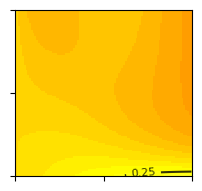

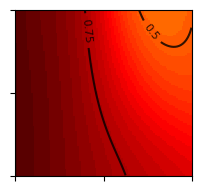

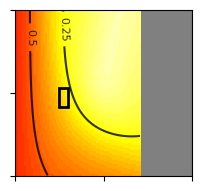

In [21]:


path_1_M_L = "figures/Fig_1/I(pol,hom)_M_L.pdf"
path_1_M_H = "figures/Fig_1/I(pol,hom)_M_H.pdf"
path_2_M = "figures/Fig_2/I(pol,hom,mean)_M.pdf"


fig_R_M_1_L = plot_multiple_metrics(
    RM_1_L, 
    metrics=["infections"],
    cmaps=cmaps, 
    contour_values=contour_values,
    contour_colors=contour_colors,
    final_params=final_params,
    #rect_coords = rect_coords_T,
    save_path=path_1_M_L
)
fig_R_M_1_H = plot_multiple_metrics(
    RM_1_H, 
    metrics=["infections"],
    cmaps=cmaps, 
    contour_values=contour_values,
    contour_colors=contour_colors,
    final_params=final_params,
    #rect_coords = rect_coords_T,
    save_path=path_1_M_H
)
fig_R_M_2 = plot_multiple_metrics(
    RM_2, 
    metrics=["infections"],
    cmaps=cmaps, 
    contour_values=contour_values,
    contour_colors=contour_colors,
    final_params=final_params,
    rect_coords = rect_coords_M,
    save_path=path_2_M
)

In [ ]:
path_1_T_L = "figures/Fig_1/I(pol,hom)_T_L.pdf"
path_1_T_H = "figures/Fig_1/I(pol,hom)_T_H.pdf"
path_2_T = "figures/Fig_2/I(pol,hom,mean)_T.pdf"
fig_R_T_1_L = plot_multiple_metrics(
    RT_1_L, 
    metrics=["infections"],
    cmaps=cmaps, 
    contour_values=contour_values,
    contour_colors=contour_colors,
    final_params=final_params,
    save_path=path_1_T_L
)
fig_R_T_1_H = plot_multiple_metrics(
    RT_1_H, 
    metrics=["infections"],
    cmaps=cmaps, 
    contour_values=contour_values,
    contour_colors=contour_colors,
    final_params=final_params,
    save_path=path_1_T_H
)
fig_R_T_2 = plot_multiple_metrics(
    RT_2, 
    metrics=["infections"],
    cmaps=cmaps, 
    contour_values=contour_values,
    contour_colors=contour_colors,
    final_params=final_params,
    rect_coords = rect_coords_T,
    save_path=path_2_T
)



c:\users\nel_t\documents\work\projects\pol_hom - copia\src\utils\visualization\common.py:264: UserWarning: The following kwargs were not used by contour: 'rasterized'
  contour = ax.contour(
c:\users\nel_t\documents\work\projects\pol_hom - copia\src\utils\visualization\common.py:264: UserWarning: The following kwargs were not used by contour: 'rasterized'
  contour = ax.contour(


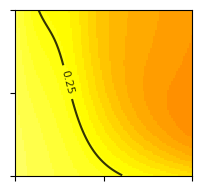

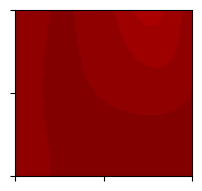

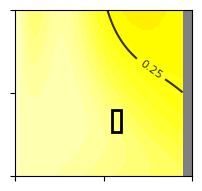

In [22]:
path_1_V_L = "figures/Fig_1/I(pol,hom)_V_L.pdf"
path_1_V_H = "figures/Fig_1/I(pol,hom)_V_H.pdf"
path_2_V = "figures/Fig_2/I(pol,hom,mean)_V.pdf"

fig_R_V_1 = plot_multiple_metrics(
    RV_1_L, 
    metrics=["infections"],
    cmaps=cmaps, 
    contour_values=contour_values,
    contour_colors=contour_colors,
    final_params=final_params,
    #rect_coords = rect_coords_V,
    save_path=path_1_V_L
)
fig_R_V_H = plot_multiple_metrics(
    RV_1_H, 
    metrics=["infections"],
    cmaps=cmaps, 
    contour_values=contour_values,
    contour_colors=contour_colors,
    final_params=final_params,
    #rect_coords = rect_coords_V,
    save_path=path_1_V_H
)


fig_R_V_2 = plot_multiple_metrics(
    RV_2, 
    metrics=["infections"],
    cmaps=cmaps, 
    contour_values=contour_values,
    contour_colors=contour_colors,
    final_params=final_params,
    rect_coords = rect_coords_V,
    save_path=path_2_V
)

C:\Users\nel_t\AppData\Local\Temp\ipykernel_16136\2860122862.py:12: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last five Jacobian evaluations.
  r_inf, = fsolve(func, 0.5)
C:\Users\nel_t\AppData\Local\Temp\ipykernel_16136\2860122862.py:12: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  r_inf, = fsolve(func, 0.5)


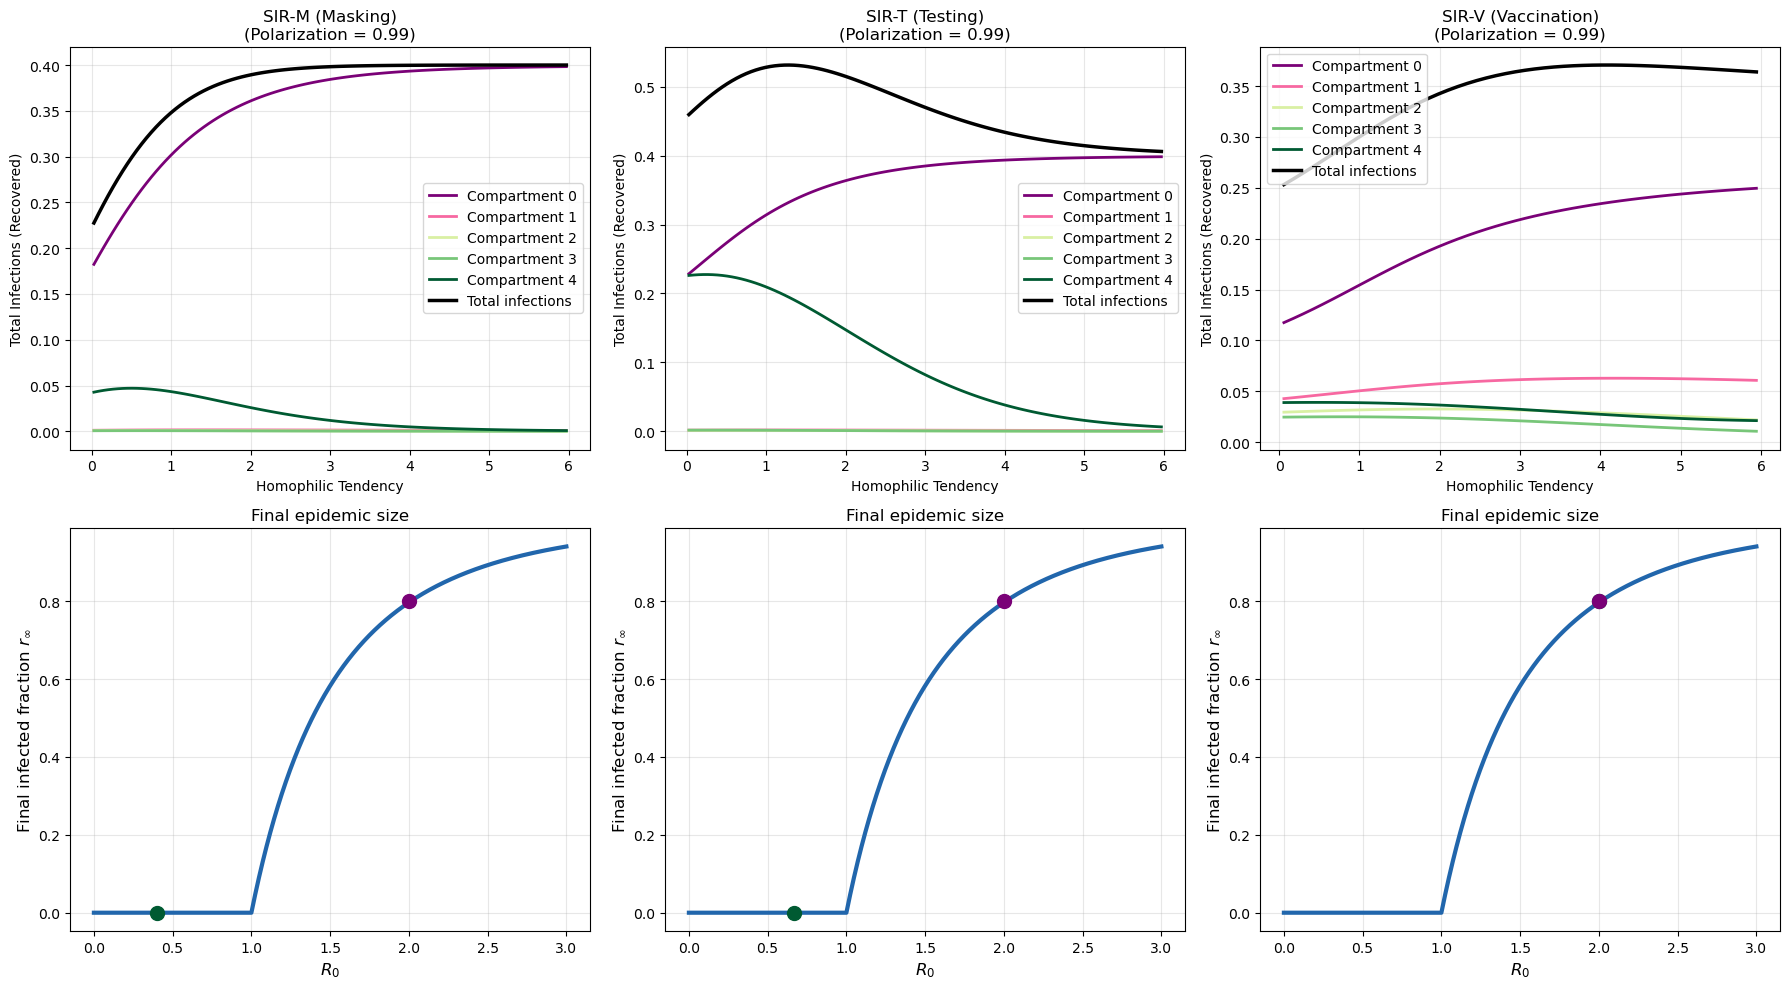

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
import matplotlib.colors as mcolors

# Create a custom colormap from purple to yellow/green
colors_custom = ['#7a0177', '#c51b8a', '#f768a1', '#fbb4b9', '#d9f0a3', '#addd8e', '#78c679', '#41ab5d', '#238443', '#005a32']

def final_size(R0):
    """Return final epidemic size r_inf for given R0."""
    func = lambda r: 1 - np.exp(-R0 * r) - r
    r_inf, = fsolve(func, 0.5)
    return r_inf

def plot_infections_by_homophily_three_models(sweep_SIRM, sweep_SIRT, sweep_SIRV, pol_value=0.5):
    """
    Plot 3x2 grid:
    Top row: 3 infections by homophily plots (one per model)
    Bottom row: 3 r_inf(R0) plots (one per model)
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    fig, axs = plt.subplots(2, 3, figsize=(18, 10))
    
    sweep_results = [sweep_SIRM, sweep_SIRT, sweep_SIRV]
    model_names = ['SIR-M (Masking)', 'SIR-T (Testing)', 'SIR-V (Vaccination)']
    
    color_indices = [0, 2, 4, 6, 9]
    compartment_colors = [colors_custom[i] for i in color_indices]
    
    # Top row: infections by homophily
    for col in range(3):
        sweep_result = sweep_results[col]
        model_name = model_names[col]
        
        pol_grid = sweep_result["parameter_grid"]["param1_vals"]
        hom_grid = sweep_result["parameter_grid"]["param2_vals"]
        
        pol_values = pol_grid[0, :]  
        pol_idx = np.argmin(np.abs(pol_values - pol_value))
        
        hom_values = hom_grid[:, pol_idx]
        
        R_data = sweep_result["final_state"]["R"]
        R_slice = R_data[:, pol_idx, :]
        
        for i in range(5):
            axs[0, col].plot(hom_values, R_slice[:, i], label=f'Compartment {i}', 
                           color=compartment_colors[i], linewidth=2)
        
        axs[0, col].plot(hom_values, np.sum(R_slice, 1), color="#000", 
                        label="Total infections", linewidth=2.5)
        
        axs[0, col].set_xlabel('Homophilic Tendency')
        axs[0, col].set_ylabel('Total Infections (Recovered)')
        axs[0, col].set_title(f'{model_name}\n(Polarization = {pol_value:.2f})')
        axs[0, col].legend()
        axs[0, col].grid(True, alpha=0.3)
    
    # Bottom row: r_inf(R0) plots
    R0_values = np.linspace(0, 3, 1000)
    final_sizes = [final_size(R0) for R0 in R0_values]
    
    for col in range(3):
        axs[1, col].plot(R0_values, final_sizes, lw=3, color='#2166ac')
        axs[1, col].set_xlabel(r"$R_0$", fontsize=12)
        axs[1, col].set_ylabel(r"Final infected fraction $r_\infty$", fontsize=12)
        axs[1, col].set_title(f"Final epidemic size", fontsize=12)
        axs[1, col].grid(True, alpha=0.3)
    
    axs[1,0].plot(0.4,0,'o',markersize=10,color=colors_custom[-1])
    axs[1,0].plot(2,0.8,'o',markersize=10,color=colors_custom[0])
    
    axs[1,1].plot(0.2/(0.1+0.2),0,'o',markersize=10,color=colors_custom[-1])
    axs[1,1].plot(2,0.8,'o',markersize=10,color=colors_custom[0])
    
    axs[1,2].plot(2,0.8,'o',markersize=10,color=colors_custom[-1])
    axs[1,2].plot(2,0.8,'o',markersize=10,color=colors_custom[0])
    

    plt.tight_layout()
    return fig
# Use it
fig = plot_infections_by_homophily_three_models(RM_1, RT_1, RV_1, pol_value=0.99)
plt.show()

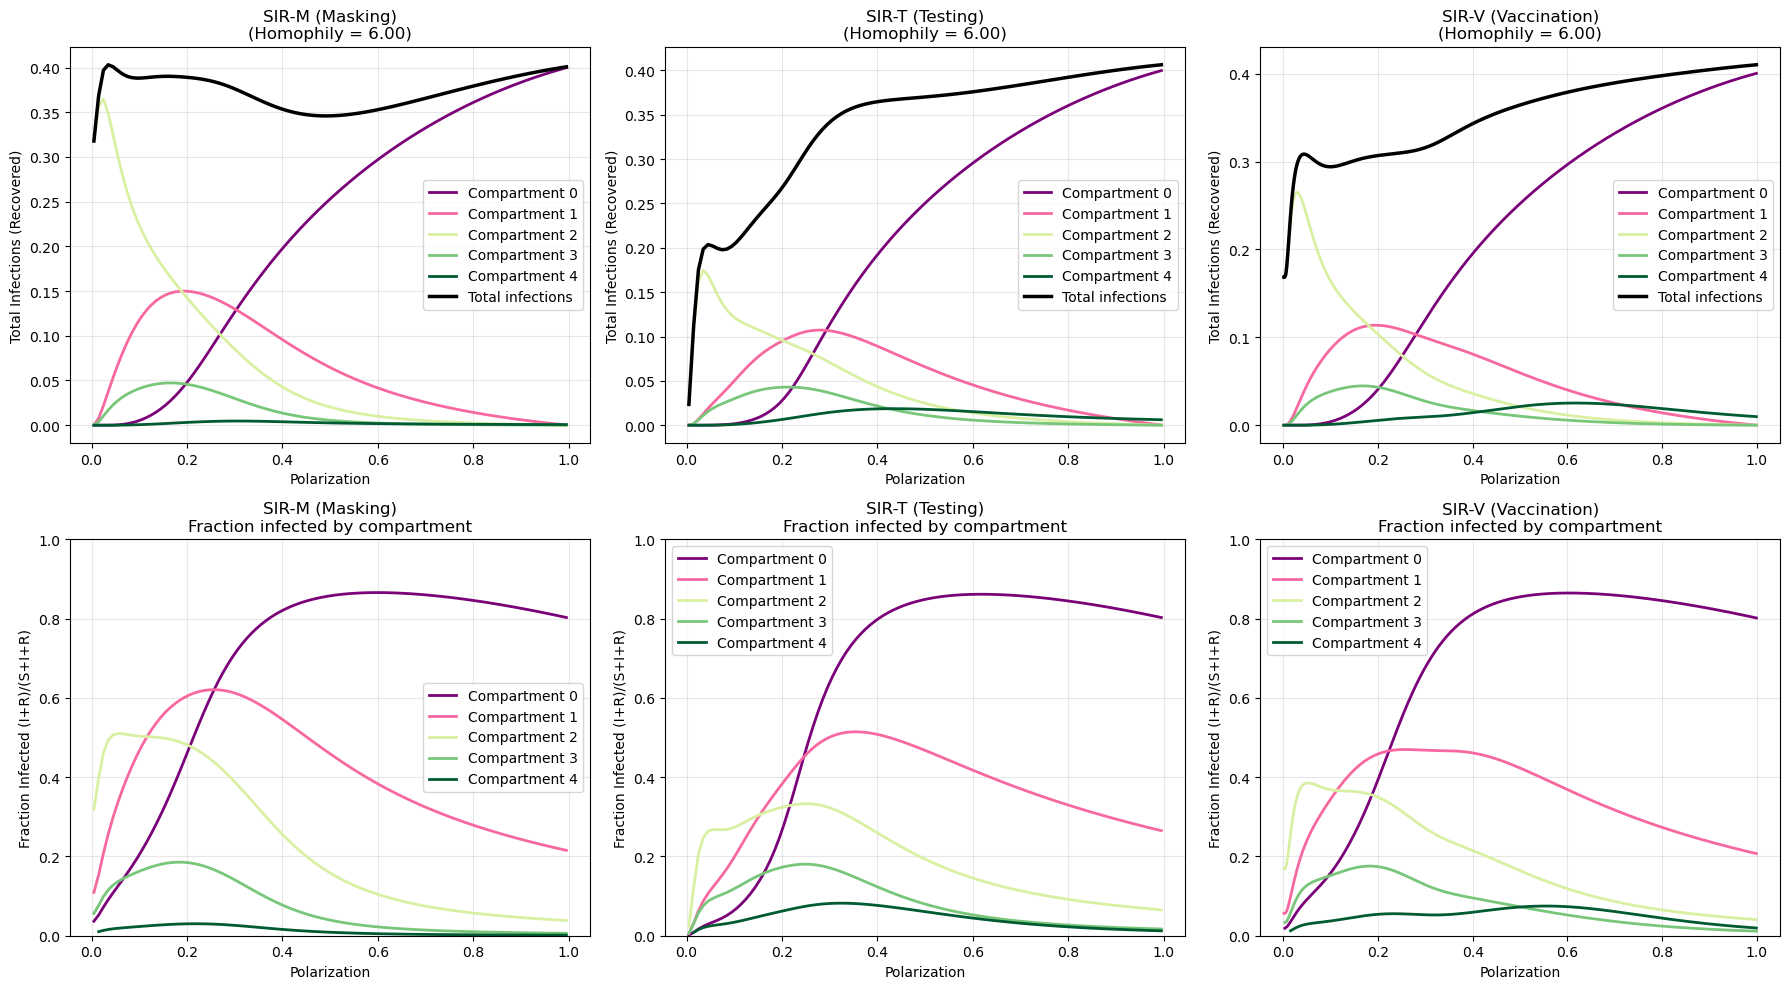

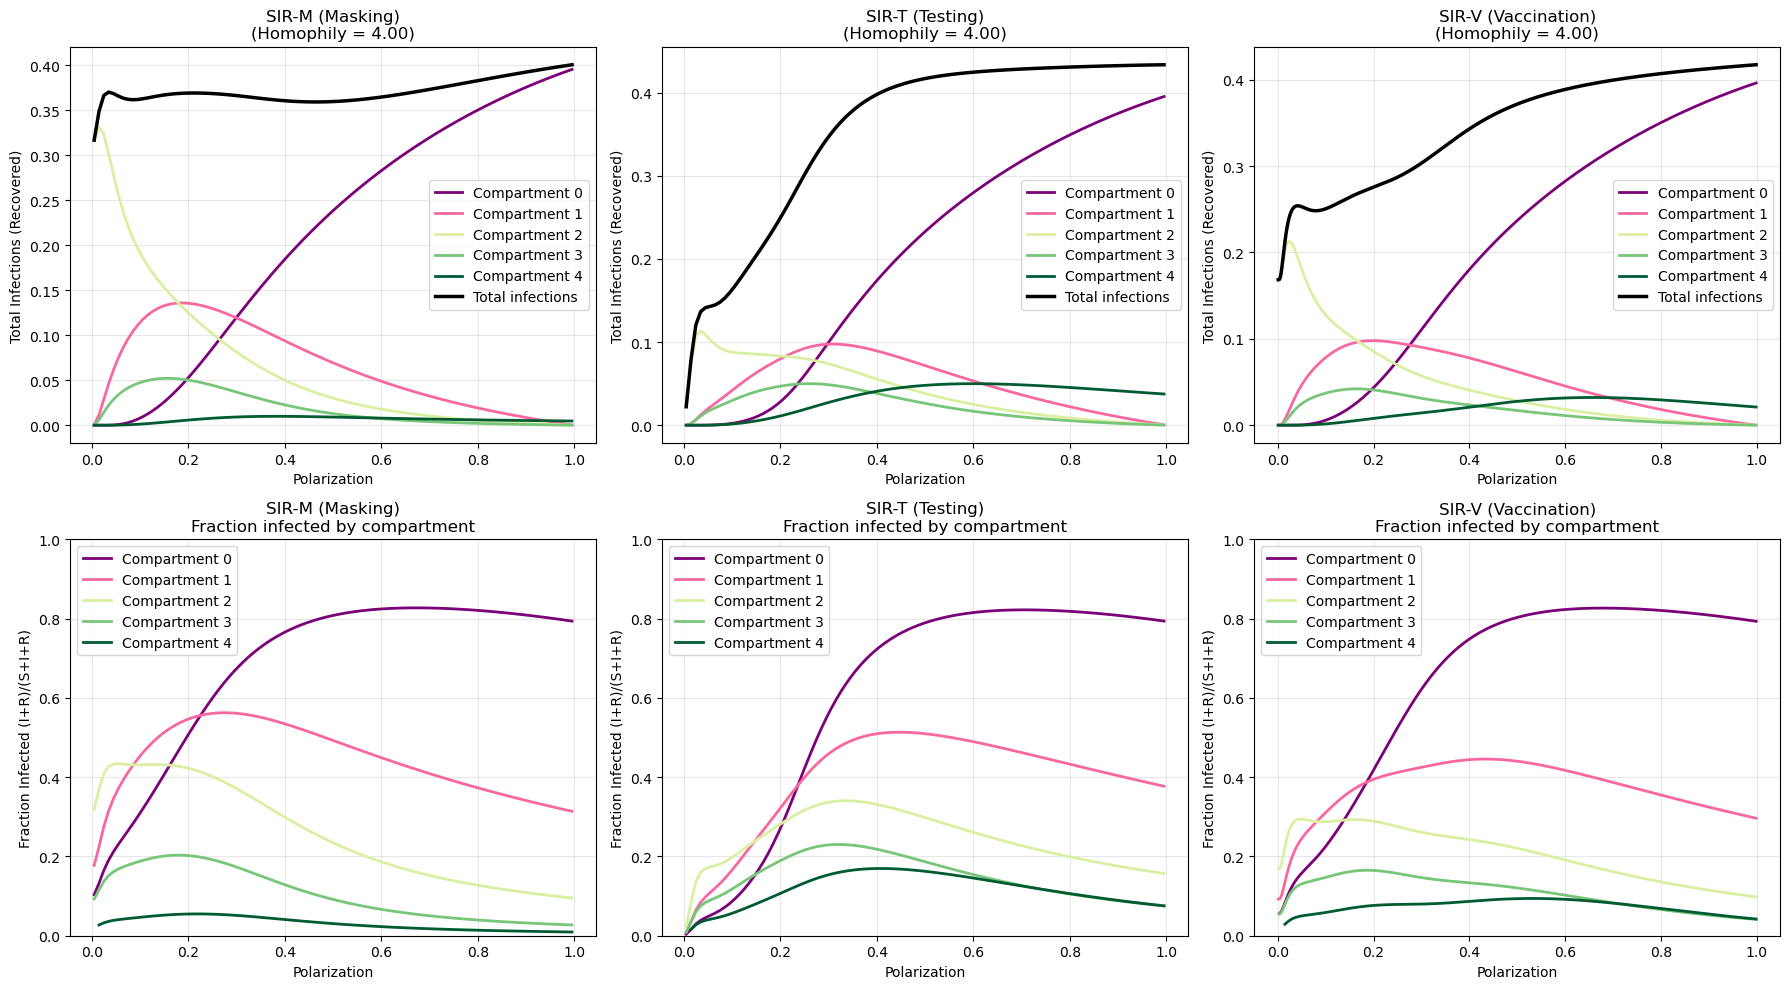

In [70]:
def plot_infections_by_polarization_three_models(sweep_SIRM, sweep_SIRT, sweep_SIRV, hom_value=6.0):
    """
    Plot 3x2 grid:
    Top row: 3 infections by polarization plots (one per model)
    Bottom row: 3 fraction infected by compartment plots (one per model)
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    fig, axs = plt.subplots(2, 3, figsize=(18, 10))
    
    sweep_results = [sweep_SIRM, sweep_SIRT, sweep_SIRV]
    model_names = ['SIR-M (Masking)', 'SIR-T (Testing)', 'SIR-V (Vaccination)']
    
    color_indices = [0, 2, 4, 6, 9]
    compartment_colors = [colors_custom[i] for i in color_indices]
    
    # Top row: infections by polarization
    for col in range(3):
        sweep_result = sweep_results[col]
        model_name = model_names[col]
        
        pol_grid = sweep_result["parameter_grid"]["param1_vals"]
        hom_grid = sweep_result["parameter_grid"]["param2_vals"]
        
        hom_values = hom_grid[:, 0]
        hom_idx = np.argmin(np.abs(hom_values - hom_value))
        
        pol_values = pol_grid[hom_idx, :]
        
        R_data = sweep_result["final_state"]["R"]
        R_slice = R_data[hom_idx, :, :]
        
        for i in range(5):
            axs[0, col].plot(pol_values, R_slice[:, i], label=f'Compartment {i}', 
                           color=compartment_colors[i], linewidth=2)
        
        axs[0, col].plot(pol_values, np.sum(R_slice, 1), color="#000", 
                        label="Total infections", linewidth=2.5)
        
        axs[0, col].set_xlabel('Polarization')
        axs[0, col].set_ylabel('Total Infections (Recovered)')
        axs[0, col].set_title(f'{model_name}\n(Homophily = {hom_value:.2f})')
        axs[0, col].legend()
        axs[0, col].grid(True, alpha=0.3)
    
    # Bottom row: fraction infected by compartment
    for col in range(3):
        sweep_result = sweep_results[col]
        model_name = model_names[col]
        
        pol_grid = sweep_result["parameter_grid"]["param1_vals"]
        hom_grid = sweep_result["parameter_grid"]["param2_vals"]
        
        hom_values = hom_grid[:, 0]
        hom_idx = np.argmin(np.abs(hom_values - hom_value))
        
        pol_values = pol_grid[hom_idx, :]
        
        S_data = sweep_result["final_state"]["S"]
        I_data = sweep_result["final_state"]["I"]
        R_data = sweep_result["final_state"]["R"]
        
        S_slice = S_data[hom_idx, :, :]
        I_slice = I_data[hom_idx, :, :]
        R_slice = R_data[hom_idx, :, :]
        
        total_population = S_slice + I_slice + R_slice
        if col == 2:
            V_data = sweep_result["final_state"]["V"]
            V_slice = V_data[hom_idx, :, :]
            total_population += V_slice
        fraction_infected = (I_slice + R_slice) / total_population
        
        
        for i in range(5):
            axs[1, col].plot(pol_values, fraction_infected[:, i], 
                           label=f'Compartment {i}', 
                           color=compartment_colors[i], linewidth=2)
        
        axs[1, col].set_xlabel('Polarization')
        axs[1, col].set_ylabel('Fraction Infected (I+R)/(S+I+R)')
        axs[1, col].set_title(f'{model_name}\nFraction infected by compartment')
        axs[1, col].legend()
        axs[1, col].grid(True, alpha=0.3)
        axs[1, col].set_ylim([0, 1])
    
    plt.tight_layout()
    return fig

# Use it
fig = plot_infections_by_polarization_three_models(RM_1, RT_1, RV_1, hom_value=6.0)
plt.show()

fig = plot_infections_by_polarization_three_models(RM_1, RT_1, RV_1, hom_value=4.0)
plt.show()

C:\Users\nel_t\AppData\Local\Temp\ipykernel_14744\1507510711.py:12: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last five Jacobian evaluations.
  r_inf, = fsolve(func, 0.5)
C:\Users\nel_t\AppData\Local\Temp\ipykernel_14744\1507510711.py:12: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  r_inf, = fsolve(func, 0.5)


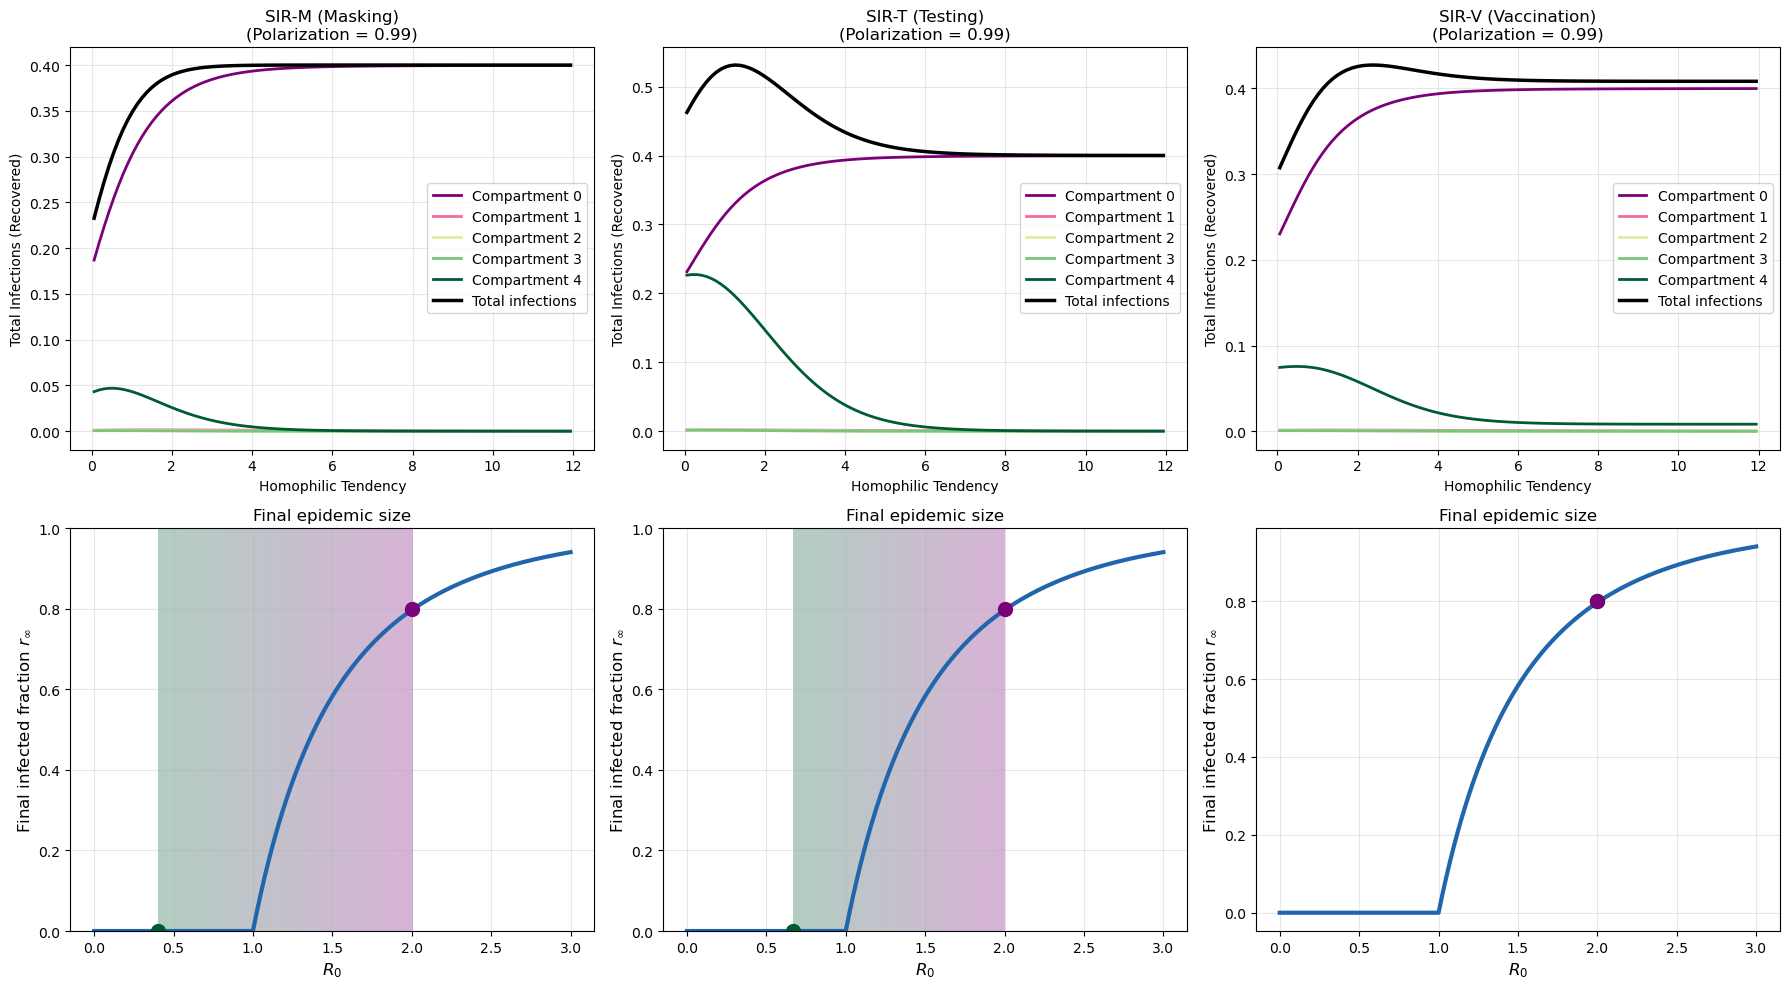

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
import matplotlib.colors as mcolors

# Create a custom colormap from purple to yellow/green
colors_custom = ['#7a0177', '#c51b8a', '#f768a1', '#fbb4b9', '#d9f0a3', '#addd8e', '#78c679', '#41ab5d', '#238443', '#005a32']

def final_size(R0):
    """Return final epidemic size r_inf for given R0."""
    func = lambda r: 1 - np.exp(-R0 * r) - r
    r_inf, = fsolve(func, 0.5)
    return r_inf

def plot_infections_by_homophily_three_models(sweep_SIRM, sweep_SIRT, sweep_SIRV, pol_value=0.5):
    """
    Plot 3x2 grid:
    Top row: 3 infections by homophily plots (one per model)
    Bottom row: 3 r_inf(R0) plots (one per model)
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    fig, axs = plt.subplots(2, 3, figsize=(18, 10))
    
    sweep_results = [sweep_SIRM, sweep_SIRT, sweep_SIRV]
    model_names = ['SIR-M (Masking)', 'SIR-T (Testing)', 'SIR-V (Vaccination)']
    
    color_indices = [0, 2, 4, 6, 9]
    compartment_colors = [colors_custom[i] for i in color_indices]
    
    # Top row: infections by homophily
    for col in range(3):
        sweep_result = sweep_results[col]
        model_name = model_names[col]
        
        pol_grid = sweep_result["parameter_grid"]["param1_vals"]
        hom_grid = sweep_result["parameter_grid"]["param2_vals"]
        
        pol_values = pol_grid[0, :]  
        pol_idx = np.argmin(np.abs(pol_values - pol_value))
        
        hom_values = hom_grid[:, pol_idx]
        
        R_data = sweep_result["final_state"]["R"]
        R_slice = R_data[:, pol_idx, :]
        
        for i in range(5):
            axs[0, col].plot(hom_values, R_slice[:, i], label=f'Compartment {i}', 
                           color=compartment_colors[i], linewidth=2)
        
        axs[0, col].plot(hom_values, np.sum(R_slice, 1), color="#000", 
                        label="Total infections", linewidth=2.5)
        
        axs[0, col].set_xlabel('Homophilic Tendency')
        axs[0, col].set_ylabel('Total Infections (Recovered)')
        axs[0, col].set_title(f'{model_name}\n(Polarization = {pol_value:.2f})')
        axs[0, col].legend()
        axs[0, col].grid(True, alpha=0.3)
    
    # Bottom row: r_inf(R0) plots
    R0_values = np.linspace(0, 3, 1000)
    final_sizes = [final_size(R0) for R0 in R0_values]
    
    for col in range(3):
        axs[1, col].plot(R0_values, final_sizes, lw=3, color='#2166ac')
        axs[1, col].set_xlabel(r"$R_0$", fontsize=12)
        axs[1, col].set_ylabel(r"Final infected fraction $r_\infty$", fontsize=12)
        axs[1, col].set_title(f"Final epidemic size", fontsize=12)
        axs[1, col].grid(True, alpha=0.3)
    
    # Add gradient-filled rectangles for first two plots
    for col in range(2):
        # Green point coordinates
        green_R0 = 0.4 if col == 0 else 0.2/(0.1+0.2)
        
        # Purple point coordinates
        purple_R0 = 2
        purple_rinf = final_size(purple_R0)
        
        # Create gradient rectangle
        # Get axis limits
        y_max = 1
        y_min = 0
        
        # Create a gradient using imshow
        gradient = np.linspace(0, 1, 256).reshape(1, -1)
        
        # Create custom colormap from green to purple
        cmap = mcolors.LinearSegmentedColormap.from_list(
            'green_purple', 
            [colors_custom[-1], colors_custom[0]]
        )
        
        axs[1, col].imshow(
            gradient,
            extent=[green_R0, purple_R0, y_min, y_max],
            aspect='auto',
            alpha=0.3,
            cmap=cmap,
            zorder=0
        )
    
    # Plot the marker points
    axs[1,0].plot(0.4, 0, 'o', markersize=10, color=colors_custom[-1])
    axs[1,0].plot(2, 0.8, 'o', markersize=10, color=colors_custom[0])
    
    axs[1,1].plot(0.2/(0.1+0.2), 0, 'o', markersize=10, color=colors_custom[-1])
    axs[1,1].plot(2, 0.8, 'o', markersize=10, color=colors_custom[0])
    
    axs[1,2].plot(2, 0.8, 'o', markersize=10, color=colors_custom[-1])
    axs[1,2].plot(2, 0.8, 'o', markersize=10, color=colors_custom[0])
    
    plt.tight_layout()
    return fig

# Use it
fig = plot_infections_by_homophily_three_models(RM_1, RT_1, RV_1, pol_value=0.99)
plt.show()

fig.savefig("figures/SI/explanation.pdf")

In [48]:
0.2/(0.1+0.198)

0.6711409395973154

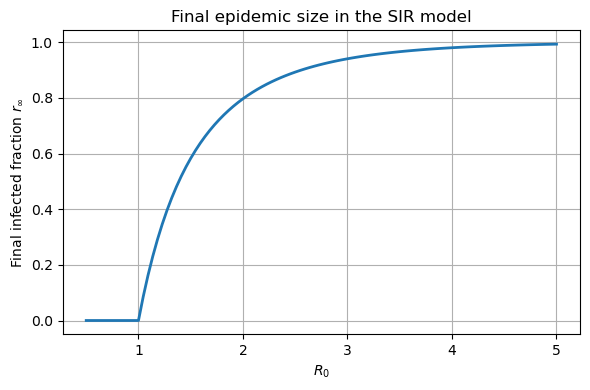

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

def final_size(R0):
    """Return final epidemic size r_inf for given R0."""
    func = lambda r: 1 - np.exp(-R0 * r) - r
    r_inf, = fsolve(func, 0.5)  # good initial guess
    return r_inf

# Range of R0 values
R0_values = np.linspace(0.5, 5, 100)
final_sizes = [final_size(R0) for R0 in R0_values]

# Plot
plt.figure(figsize=(6,4))
plt.plot(R0_values, final_sizes, lw=2)
plt.xlabel(r"$R_0$")
plt.ylabel("Final infected fraction $r_\\infty$")
plt.title("Final epidemic size in the SIR model")
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\nel_t\AppData\Local\Temp\ipykernel_14744\1251015167.py:12: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  r_inf, = fsolve(func, 0.5)
C:\Users\nel_t\AppData\Local\Temp\ipykernel_14744\1251015167.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


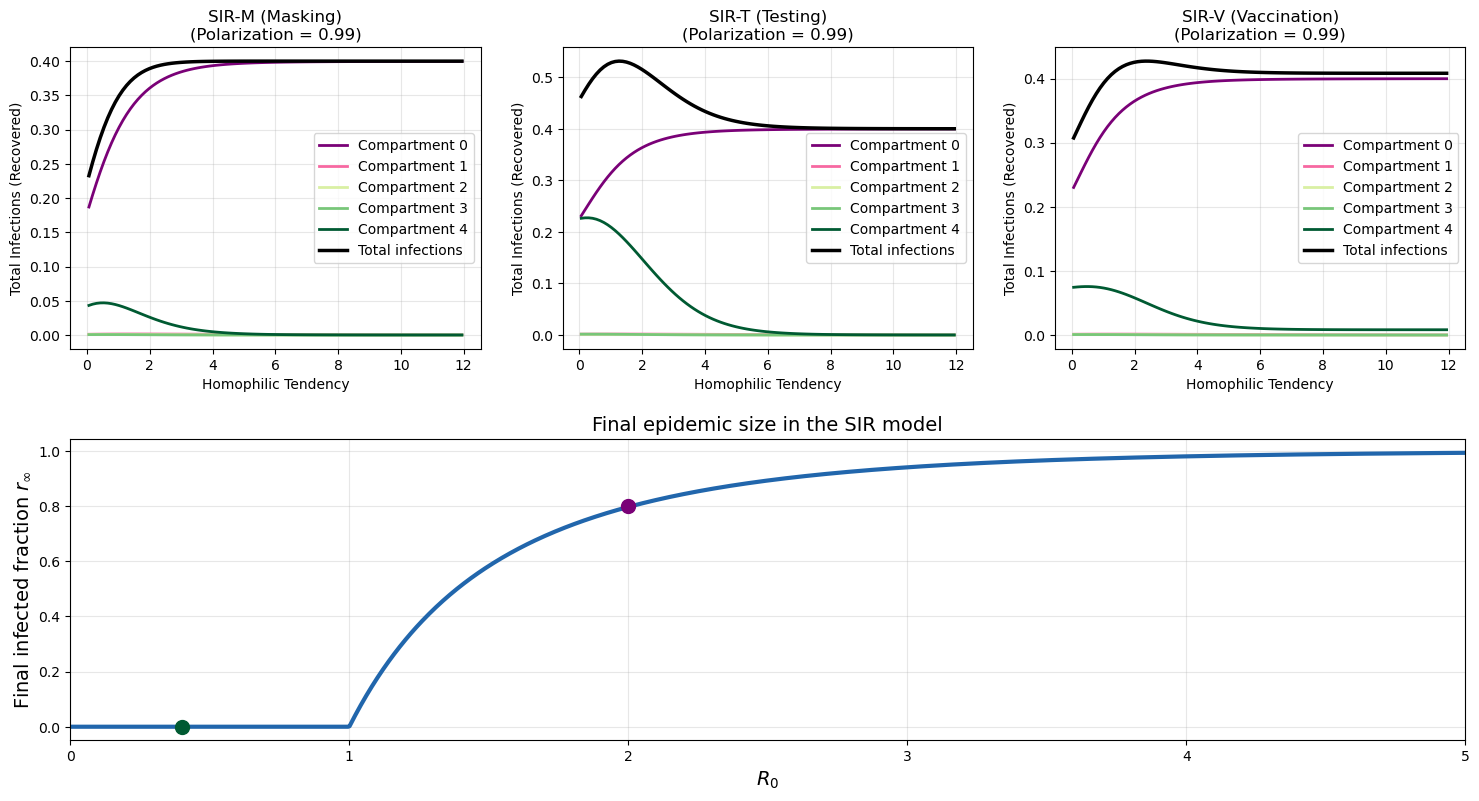

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
import matplotlib.colors as mcolors

# Create a custom colormap from purple to yellow/green
colors_custom = ['#7a0177', '#c51b8a', '#f768a1', '#fbb4b9', '#d9f0a3', '#addd8e', '#78c679', '#41ab5d', '#238443', '#005a32']

def final_size(R0):
    """Return final epidemic size r_inf for given R0."""
    func = lambda r: 1 - np.exp(-R0 * r) - r
    r_inf, = fsolve(func, 0.5)
    return r_inf

def plot_infections_by_homophily_three_models(sweep_SIRM, sweep_SIRT, sweep_SIRV, pol_value=0.5):
    """
    Plot total infections for each compartment across homophily values
    at a fixed polarization value for three models side by side,
    with final size curve below
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Create figure with gridspec for custom layout
    fig = plt.figure(figsize=(18, 9))
    gs = fig.add_gridspec(2, 3, height_ratios=[1, 1], hspace=0.3)
    
    # Top row: three model subplots
    axes_top = [fig.add_subplot(gs[0, i]) for i in range(3)]
    
    # Bottom row: one wide subplot
    ax_bottom = fig.add_subplot(gs[1, :])
    
    sweep_results = [sweep_SIRM, sweep_SIRT, sweep_SIRV]
    model_names = ['SIR-M (Masking)', 'SIR-T (Testing)', 'SIR-V (Vaccination)']
    
    # Select 5 colors evenly spaced from the custom colormap
    color_indices = [0, 2, 4, 6, 9]
    compartment_colors = [colors_custom[i] for i in color_indices]
    
    for ax, sweep_result, model_name in zip(axes_top, sweep_results, model_names):
        # Get the parameter grids
        pol_grid = sweep_result["parameter_grid"]["param1_vals"]
        hom_grid = sweep_result["parameter_grid"]["param2_vals"]
        
        # Find the index closest to desired polarization
        pol_values = pol_grid[0, :]  
        pol_idx = np.argmin(np.abs(pol_values - pol_value))
        
        # Extract the slice: all homophily values, fixed polarization
        hom_values = hom_grid[:, pol_idx]
        
        # Get recovered (= total infected) for each compartment
        R_data = sweep_result["final_state"]["R"]
        R_slice = R_data[:, pol_idx, :]
        
        # Plot each compartment
        for i in range(5):
            ax.plot(hom_values, R_slice[:, i], label=f'Compartment {i}', 
                   color=compartment_colors[i], linewidth=2)
        
        # Plot total
        ax.plot(hom_values, np.sum(R_slice, 1), color="#000", 
               label="Total infections", linewidth=2.5)
        
        ax.set_xlabel('Homophilic Tendency')
        ax.set_ylabel('Total Infections (Recovered)')
        ax.set_title(f'{model_name}\n(Polarization = {pol_value:.2f})')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # Bottom plot: Final size curve
    R0_values = np.linspace(0, 5, 1000)
    final_sizes = [final_size(R0) for R0 in R0_values]
    
    ax_bottom.plot(R0_values, final_sizes, lw=3, color='#2166ac')
    ax_bottom.set_xlabel(r"$R_0$", fontsize=14)
    ax_bottom.set_ylabel(r"Final infected fraction $r_\infty$", fontsize=14)
    ax_bottom.set_title("Final epidemic size in the SIR model", fontsize=14)
    ax_bottom.grid(True, alpha=0.3)
    ax_bottom.set_xlim([0,5])
    ax_bottom.plot(0.4,0,'o', markersize =10, color = '#005a32')
    ax_bottom.plot(2,  0.8,'o',markersize=10, color ='#7a0177')
    plt.tight_layout()
    return fig

# Use it
fig = plot_infections_by_homophily_three_models(RM_1, RT_1, RV_1, pol_value=0.99)
plt.show()

In [7]:
P_min_M, P_max_M = find_hpol_minmax(SIRM, mus, PARAMS)
P_min_T, P_max_T = find_hpol_minmax(SIRT, taus, PARAMS)
P_min_V, P_max_V = find_hpol_minmax(SIRV, xis, PARAMS)

Minimum R+I value: 0.0002
   at polarization = 0.2994, homophily = 3.1715
Maximum R+I value: 0.0002
   at polarization = 0.2506, homophily = 2.5085
Minimum R+I value: 0.4382
   at polarization = 0.4605, homophily = 2.0179
Maximum R+I value: 0.4602
   at polarization = 0.4995, homophily = 2.5061
Minimum R+I value: 0.2086
   at polarization = 0.5506, homophily = 1.6100
Maximum R+I value: 0.2386
   at polarization = 0.5994, homophily = 2.3900


Percentage increase in infections for M model: -55.24%


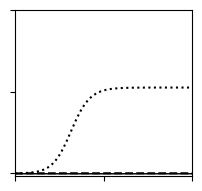

In [8]:
N_days = 1001
days = np.arange(0, N_days+1, 1)

MINS_M, MAXS_M, BASES_M, OG_M = calc_minmax_trajectories(SIRM, P_min_M, P_max_M, mus["mean"][1], PARAMS, simulated_days = N_days)
fig_comparison_M = plot_double_comparison(days, MINS_M, MAXS_M, BASES_M, OG_M, "figures/Fig_2/I(pol,hom)_M.pdf", Lx, Ly)

avg_predicted = (MINS_M[0][-1] + MINS_M[1][-1] + MAXS_M[0][-1] + MAXS_M[1][-1]) / 4

avg_base = (BASES_M[0][-1] + BASES_M[1][-1]) / 2

perc_increase = ((avg_predicted - avg_base) / avg_base) * 100
print(f"Percentage increase in infections for M model: {perc_increase:.2f}%")

increase in infections for T model: x 680.78


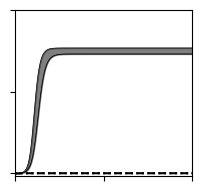

In [9]:
MINS_T, MAXS_T, BASES_T,OG_T = calc_minmax_trajectories(SIRT, P_min_T, P_max_T, taus["mean"][1], PARAMS, simulated_days = N_days)
fig_comparison_T = plot_double_comparison(days, MINS_T, MAXS_T, BASES_T, OG_T, "figures/Fig_2/I(pol,hom)_T.pdf", Lx, Ly)

avg_predicted = (MINS_T[0][-1] + MINS_T[1][-1] + MAXS_T[0][-1] + MAXS_T[1][-1]) / 4

avg_base = (BASES_T[0][-1] + BASES_T[1][-1]) / 2

perc_increase = ((avg_predicted - avg_base) / avg_base)
print(f"increase in infections for T model: x {perc_increase:.2f}")

Percentage increase in infections for V model: 128.31%


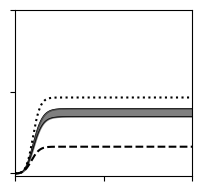

In [10]:
MINS_V, MAXS_V, BASES_V, OG_V = calc_minmax_trajectories(SIRV, P_min_V, P_max_V, xis["mean"][1], PARAMS, simulated_days = N_days)
fig_comparison_V = plot_double_comparison(days, MINS_V, MAXS_V, BASES_V, OG_V, "figures/Fig_2/I(pol,hom)_V.pdf", Lx, Ly)

avg_predicted = (MINS_V[0][-1] + MINS_V[1][-1] + MAXS_V[0][-1] + MAXS_V[1][-1]) / 4

avg_base = (BASES_V[0][-1] + BASES_V[1][-1]) / 2

perc_increase = ((avg_predicted - avg_base) / avg_base) * 100
print(f"Percentage increase in infections for V model: {perc_increase:.2f}%")

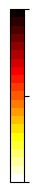

In [15]:
cbar_fig = create_standalone_colorbar(
    cmap_name=my_map,
    vmin=0,
    vmax=1,
    height=Ly,
    width=Ly/3,
    ticks=[0, 0.5, 1],
    ticklabels=[],
    save_path='figures/Fig_1/colorbar_Inf.pdf'
)